1. Загрузка данных...
Форма объединённого датасета после INNER JOIN: (1023, 13)

2. Разведочный анализ данных (EDA)...
<class 'pandas.core.frame.DataFrame'>
Index: 1023 entries, 0 to 1022
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Соотношение матрица-наполнитель       1023 non-null   float64
 1   Плотность, кг/м3                      1023 non-null   float64
 2   модуль упругости, ГПа                 1023 non-null   float64
 3   Количество отвердителя, м.%           1023 non-null   float64
 4   Содержание эпоксидных групп,%_2       1023 non-null   float64
 5   Температура вспышки, С_2              1023 non-null   float64
 6   Поверхностная плотность, г/м2         1023 non-null   float64
 7   Модуль упругости при растяжении, ГПа  1023 non-null   float64
 8   Прочность при растяжении, МПа         1023 non-null   float64
 9   Потребление смолы, г/м2              

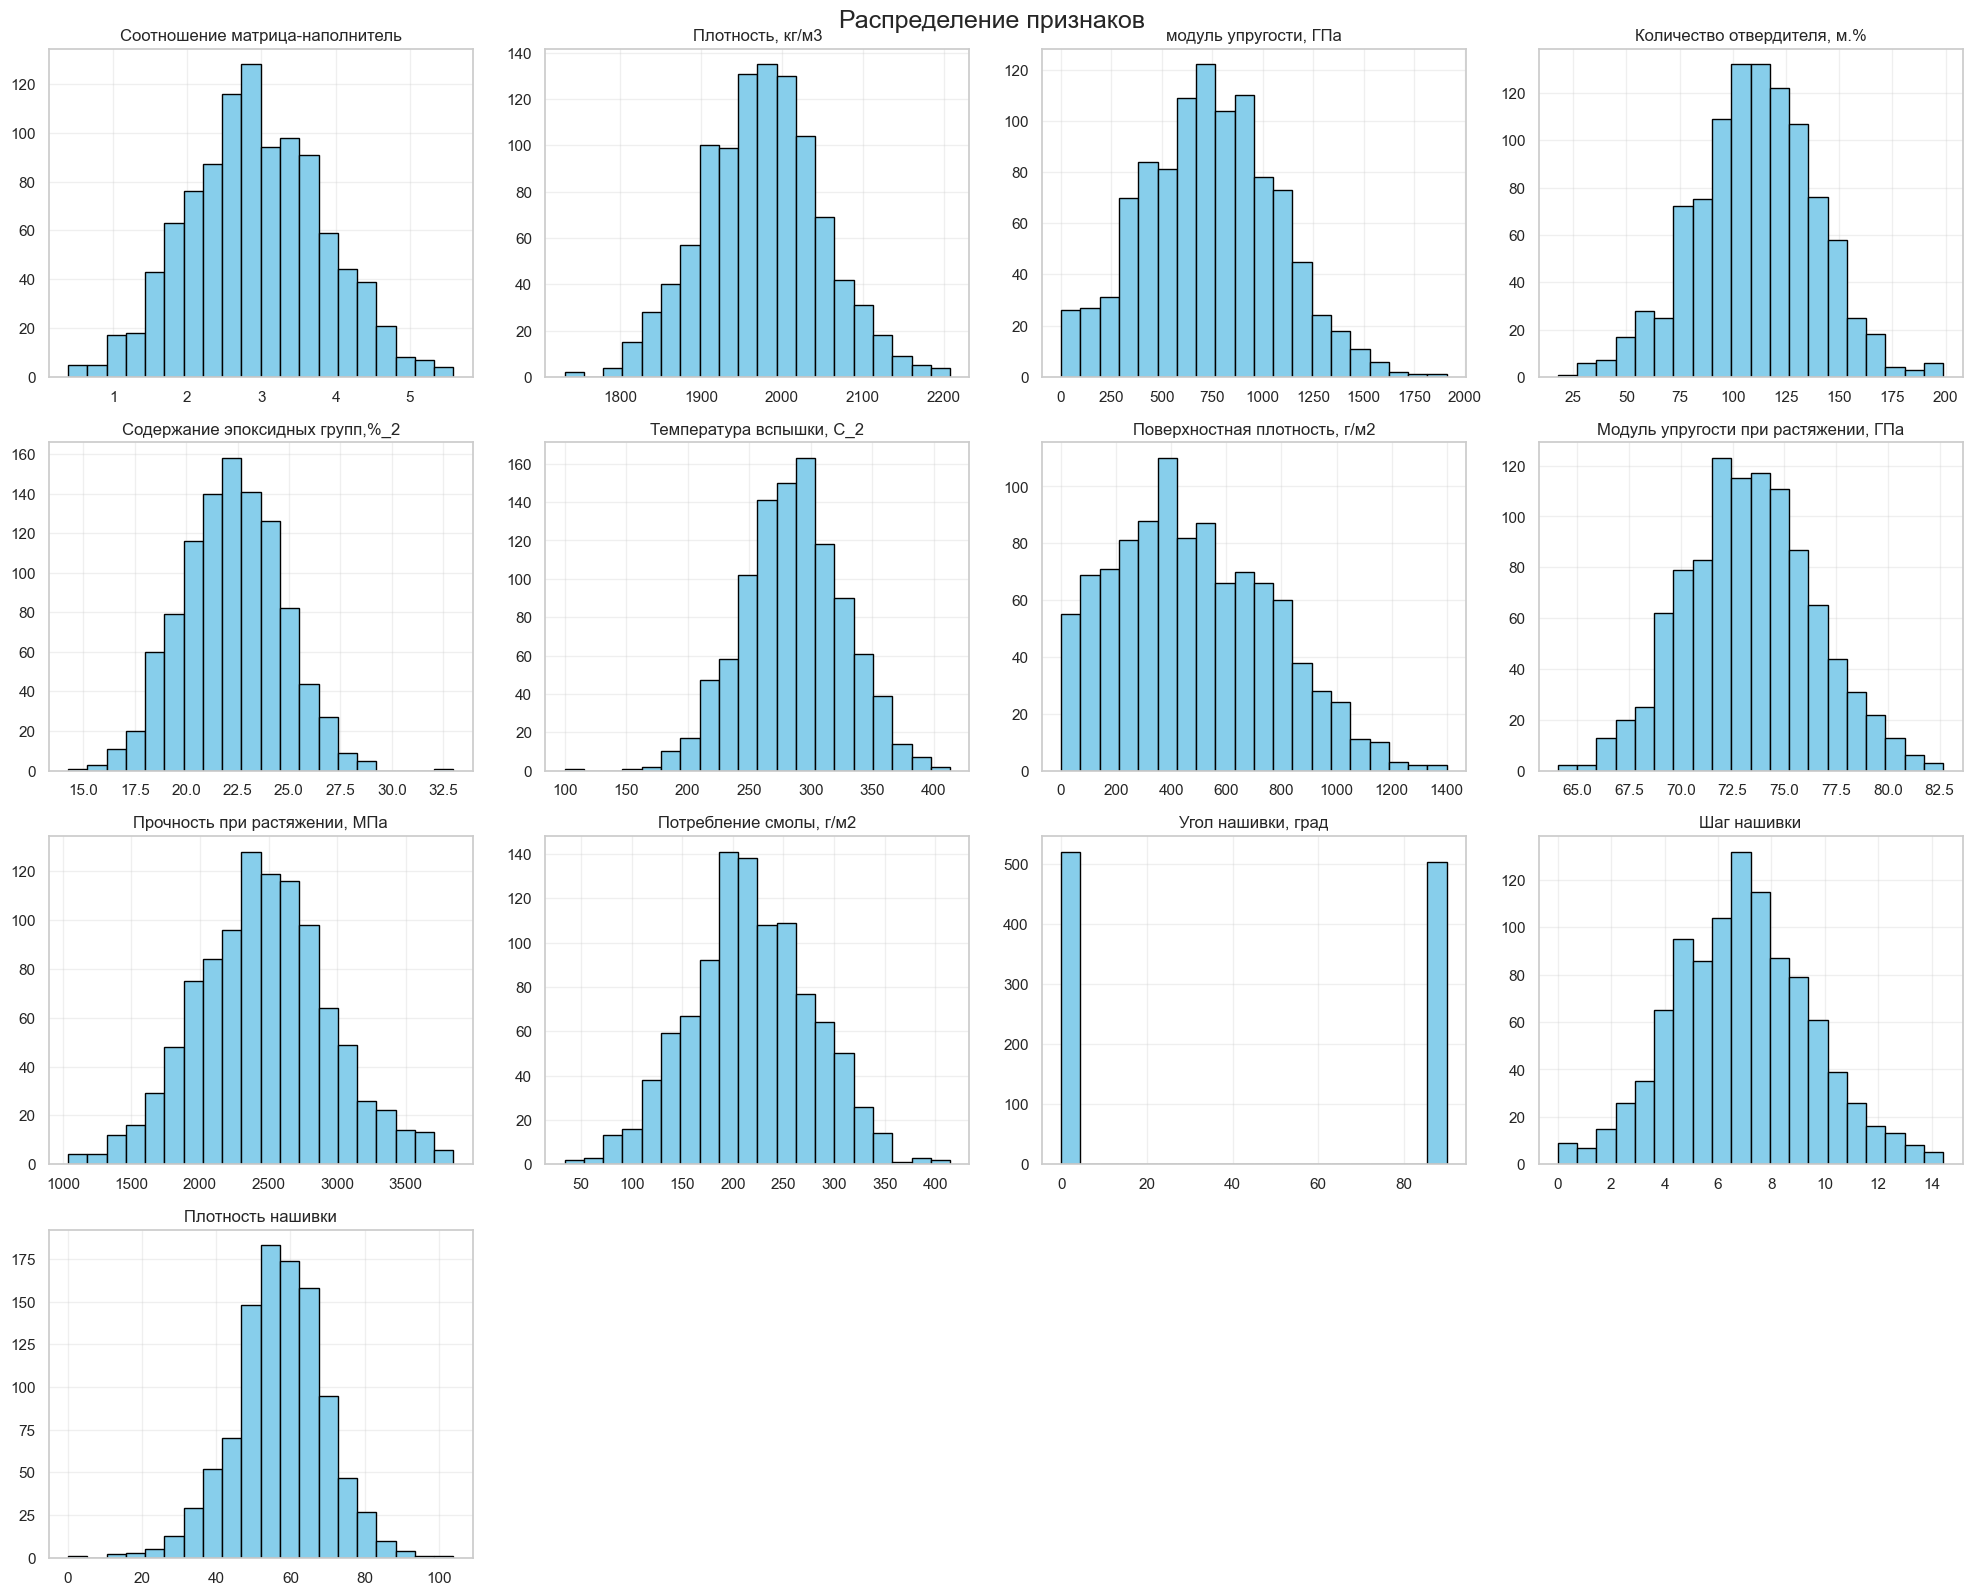

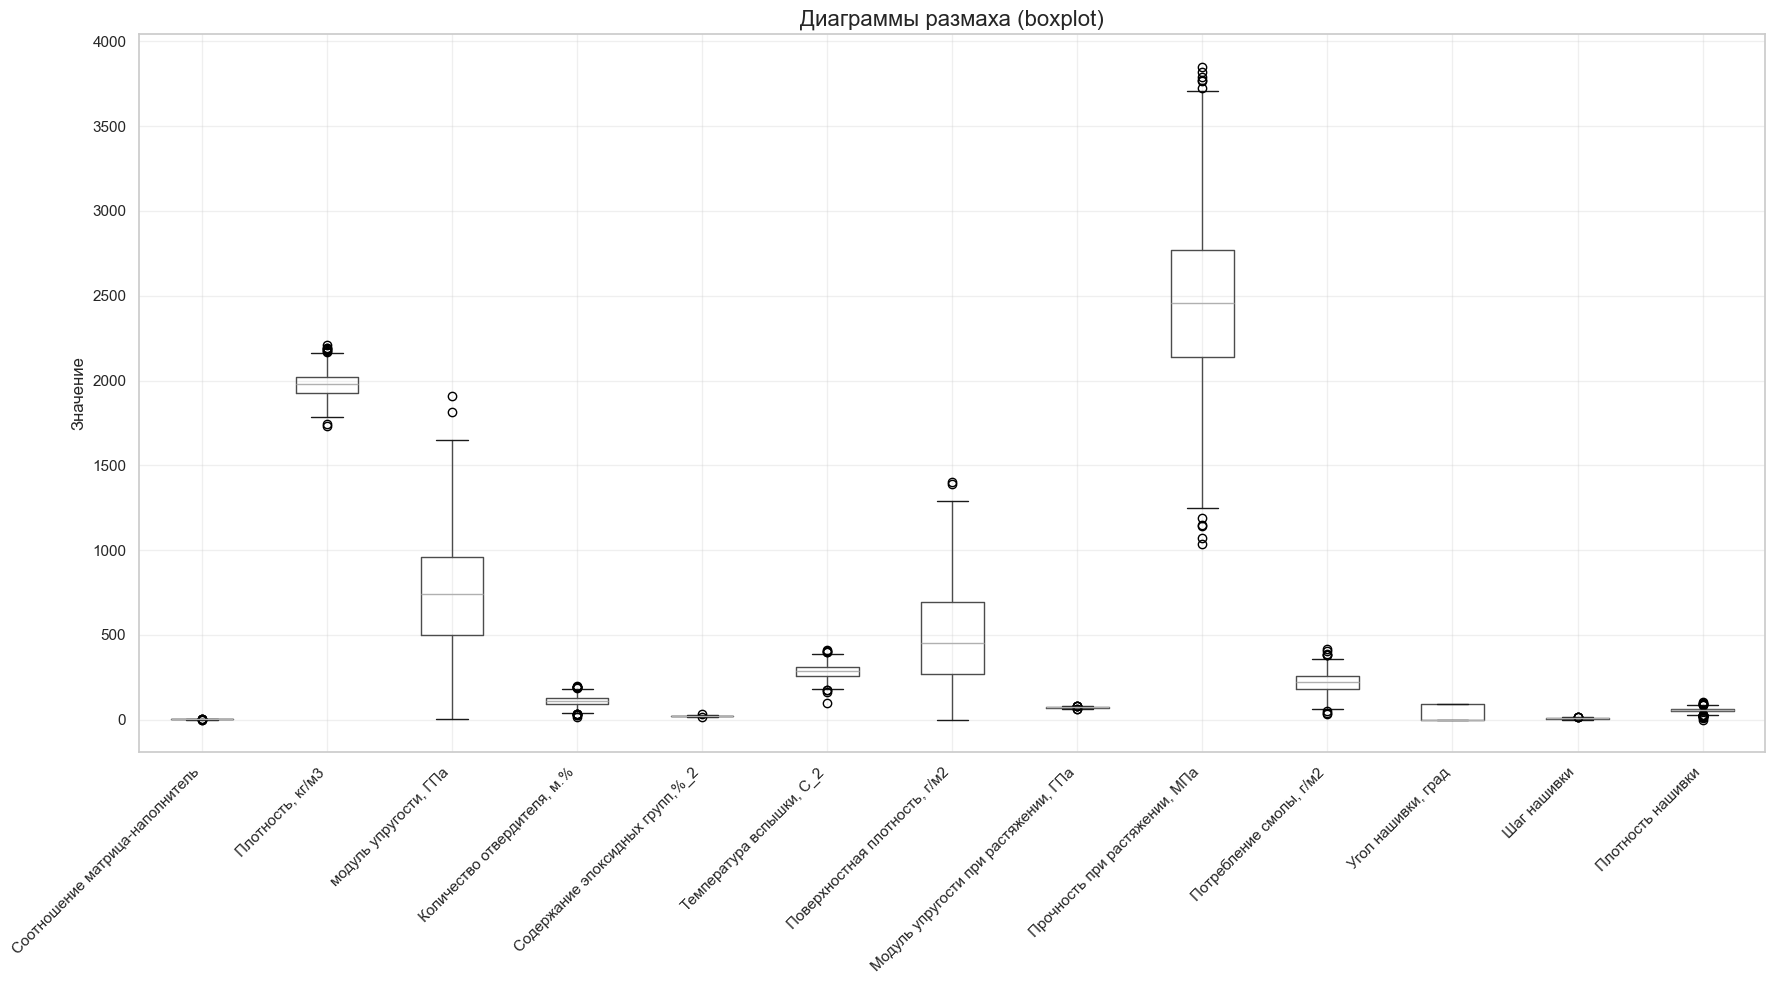

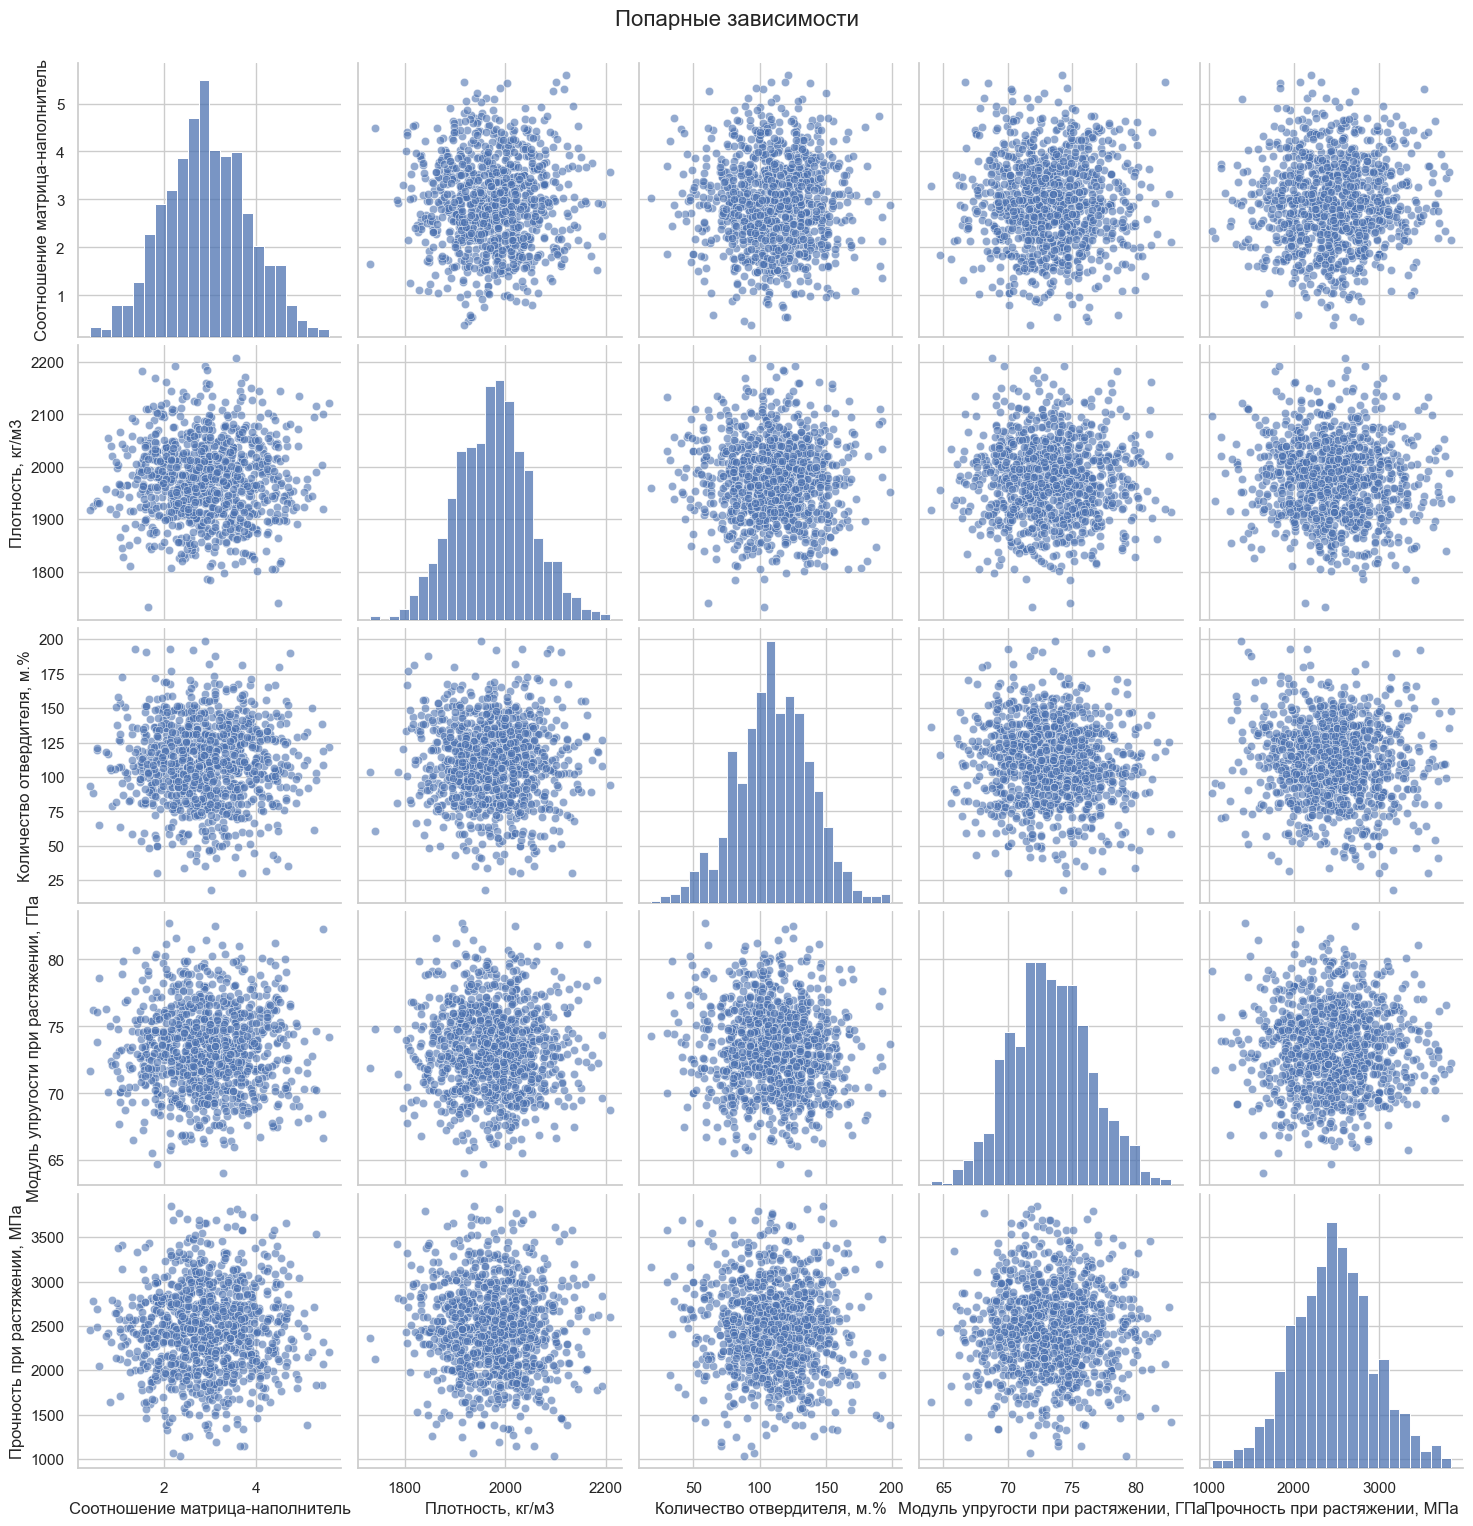

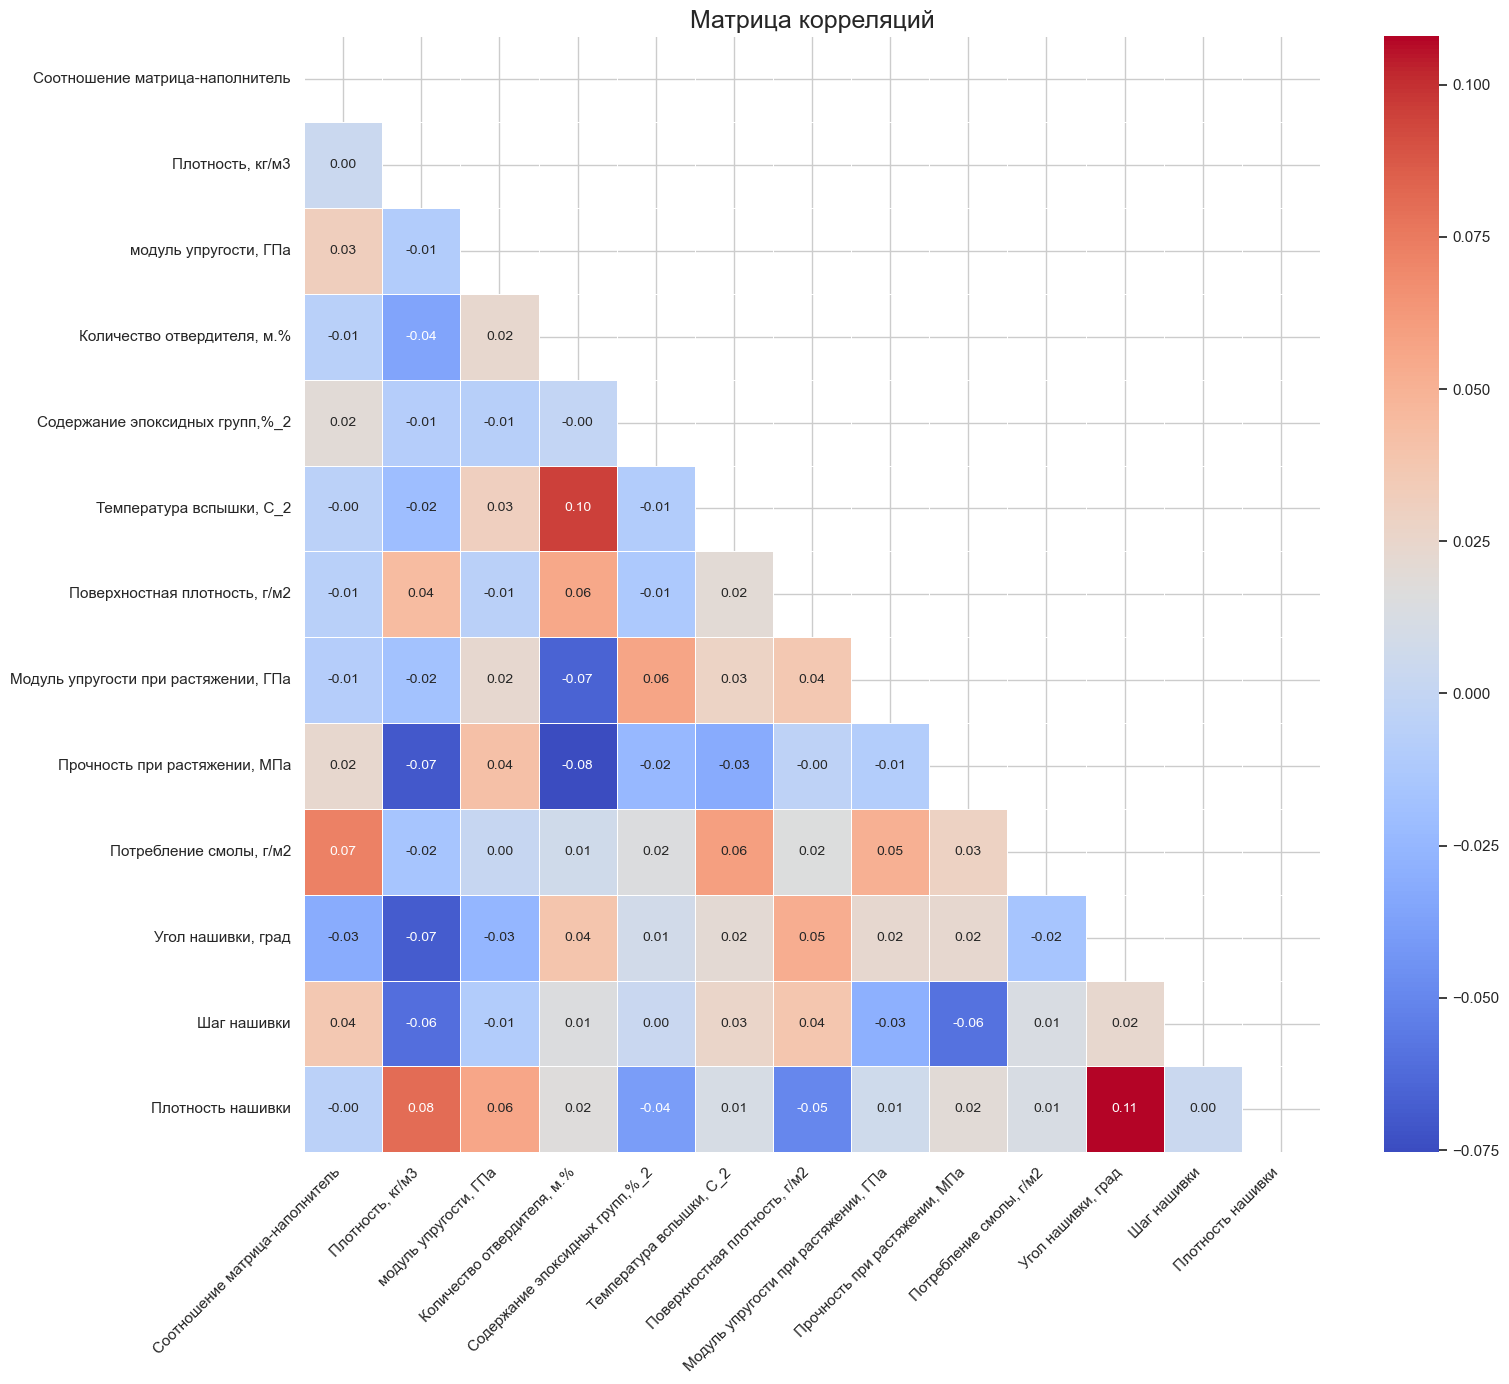


3. Предобработка данных...
После удаления выбросов: 1007 строк

5. Обучение и сравнение моделей...

Обучение модели: RandomForest
RandomForest → MAE: 185.94, RMSE: 327.59, R²: -0.0202

Обучение модели: SVR
SVR → MAE: 187.72, RMSE: 328.68, R²: -0.0062

Обучение модели: XGBoost
XGBoost → MAE: 186.81, RMSE: 328.78, R²: -0.0021

Baseline (среднее) → R²: -0.0004

Лучшая модель: XGBoost (R² = -0.0021)

6. Обратная задача: обучение нейросети...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Нейросеть → MAE: 0.7090, R²: -0.0083


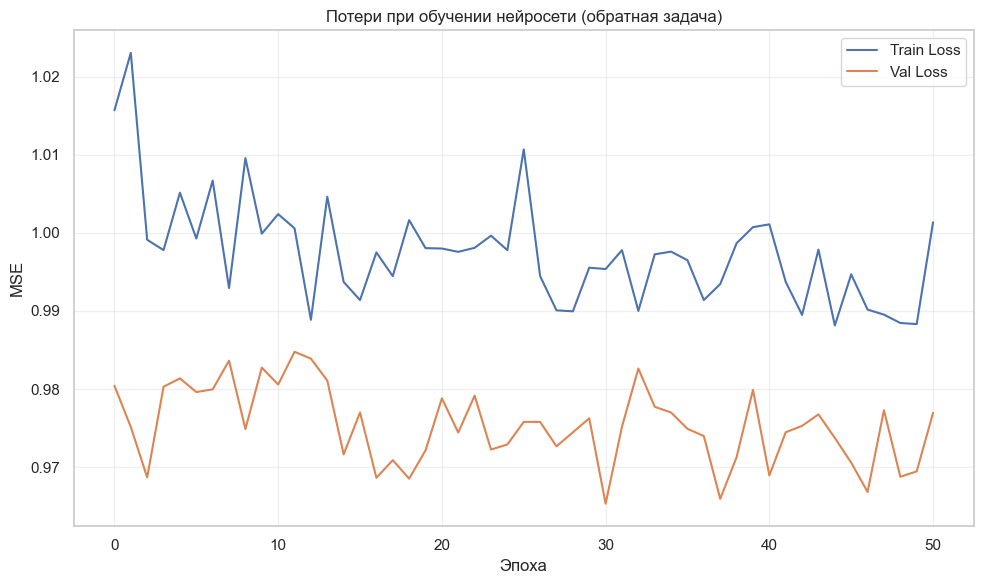


КОНСОЛЬНОЕ ПРИЛОЖЕНИЕ: Прогноз свойств композитов
1. Прогноз свойств по составу
2. Рекомендация соотношения по желаемым свойствам


Выберите режим (1 или 2):  1



Введите значения в реальных единицах измерения:


Соотношение матрица-наполнитель (допустимый диапазон: от 0.39 до 5.59):  4
Плотность, кг/м3 (допустимый диапазон: от 1731.76 до 2207.77):  1893
модуль упругости, ГПа (допустимый диапазон: от 2.44 до 1911.54):  1900.98
Количество отвердителя, м.% (допустимый диапазон: от 17.74 до 198.95):  167.34
Содержание эпоксидных групп,%_2 (допустимый диапазон: от 14.25 до 33.00):  22
Температура вспышки, С_2 (допустимый диапазон: от 100.00 до 413.27):  300
Поверхностная плотность, г/м2 (допустимый диапазон: от 0.60 до 1399.54):  1399
Потребление смолы, г/м2 (допустимый диапазон: от 33.80 до 414.59):  401
Угол нашивки, град (допустимый диапазон: от 0.00 до 90.00):  76.5
Шаг нашивки (допустимый диапазон: от 0.00 до 14.44):  13.1
Плотность нашивки (допустимый диапазон: от 0.00 до 103.99):  100



Прогноз:
  Модуль упругости при растяжении, ГПа: 73.23
  Прочность при растяжении, МПа: 2325.28


In [2]:
"""
ВКР: Прогнозирование конечных свойств новых композиционных материалов
Курс: Data Science PRO
Студентка: Бинеева Амина Олеговна
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.dummy import DummyRegressor

import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

# --- 1. Загрузка данных ---
print("1. Загрузка данных...")
df_bp = pd.read_excel("C://Users/amina/Desktop/X_bp.xlsx")
df_nup = pd.read_excel("C://Users/amina/Desktop/X_nup.xlsx")

# Удаление Unnamed колонок
df_bp = df_bp.loc[:, ~df_bp.columns.str.contains('^Unnamed')]
df_nup = df_nup.loc[:, ~df_nup.columns.str.contains('^Unnamed')]

# INNER JOIN по индексу
df = df_bp.join(df_nup, how='inner')
print(f"Форма объединённого датасета после INNER JOIN: {df.shape}")

# --- 2. Разведочный анализ данных (EDA) ---
print("\n2. Разведочный анализ данных (EDA)...")
df.info()

missing = df.isnull().sum()
if missing.sum() > 0:
    print("\nПропуски:")
    print(missing[missing > 0])
else:
    print("\nПропуски отсутствуют.")

numeric_cols = df.select_dtypes(include=[np.number]).columns
print("\nСтатистики числовых признаков:")
print(df[numeric_cols].describe())

# --- Гистограммы ---
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    if i < len(axes):
        df[col].hist(bins=20, ax=axes[i], color='skyblue', edgecolor='black')
        axes[i].set_title(col, fontsize=12)
        axes[i].grid(True, alpha=0.3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Распределение признаков', fontsize=18)
plt.tight_layout()
plt.savefig('eda_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Boxplot ---
plt.figure(figsize=(18, 10))
df[numeric_cols].boxplot()
plt.xticks(rotation=45, ha='right')
plt.title('Диаграммы размаха (boxplot)', fontsize=16)
plt.ylabel('Значение')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Pairplot ---
target_cols = ['Модуль упругости при растяжении, ГПа', 'Прочность при растяжении, МПа']
key_features = ['Соотношение матрица-наполнитель', 'Плотность, кг/м3', 'Количество отвердителя, м.%']
subset = df[key_features + target_cols].dropna()
if not subset.empty:
    g = sns.pairplot(subset, diag_kind='hist', plot_kws={'alpha': 0.6}, height=3)
    g.fig.suptitle('Попарные зависимости', y=1.02, fontsize=16)
    plt.savefig('eda_pairplot.png', dpi=300, bbox_inches='tight')
    plt.show()

# --- Корреляция ---
plt.figure(figsize=(16, 14))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, annot_kws={"size": 10})
plt.title('Матрица корреляций', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 3. Предобработка данных ---
print("\n3. Предобработка данных...")
target_props = ['Модуль упругости при растяжении, ГПа', 'Прочность при растяжении, МПа']
input_features = [col for col in df.columns if col not in target_props]

df_clean = df.dropna(subset=target_props)

def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

df_clean = remove_outliers_iqr(df_clean, target_props[0])
df_clean = remove_outliers_iqr(df_clean, target_props[1])
print(f"После удаления выбросов: {df_clean.shape[0]} строк")

# --- 4. Подготовка данных ---
X = df_clean[input_features]
y = df_clean[target_props]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# Графики нормализации
for i, feat in enumerate(input_features[:8]):
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].hist(X_train[feat], bins=20, color='skyblue', edgecolor='black')
    ax[0].set_title(f'До нормализации\nmin={X_train[feat].min():.2f}, max={X_train[feat].max():.2f}')
    ax[1].hist(X_train_scaled[:, i], bins=20, color='lightgreen', edgecolor='black')
    ax[1].set_title(f'После нормализации\nmin={X_train_scaled[:, i].min():.2f}, max={X_train_scaled[:, i].max():.2f}')
    plt.suptitle(f'Нормализация признака: {feat}')
    plt.tight_layout()
    plt.savefig(f'norm_{feat.replace("/", "_").replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.close()

# --- 5. Обучение моделей ---
print("\n5. Обучение и сравнение моделей...")

models = {
    "RandomForest": MultiOutputRegressor(RandomForestRegressor(random_state=42, n_jobs=-1)),
    "SVR": MultiOutputRegressor(SVR()),
    "XGBoost": MultiOutputRegressor(xgb.XGBRegressor(random_state=42, n_jobs=-1))
}

param_grids = {
    "RandomForest": {
        'estimator__n_estimators': [50, 100],
        'estimator__max_depth': [10, 20, None],
        'estimator__min_samples_split': [2, 5]
    },
    "SVR": {
        'estimator__C': [0.1, 1, 10],
        'estimator__gamma': ['scale', 'auto']
    },
    "XGBoost": {
        'estimator__n_estimators': [50, 100],
        'estimator__max_depth': [3, 6],
        'estimator__learning_rate': [0.01, 0.1]
    }
}

results = {}
for name, model in models.items():
    print(f"\nОбучение модели: {name}")
    grid = GridSearchCV(model, param_grids[name], cv=10, scoring='neg_mean_absolute_error', n_jobs=-1)
    grid.fit(X_train_scaled, y_train_scaled)
    best_model = grid.best_estimator_
    y_pred_scaled = best_model.predict(X_test_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2, "model": best_model}
    print(f"{name} → MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")

# Baseline
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_scaled, y_train_scaled)
y_dummy = scaler_y.inverse_transform(dummy.predict(X_test_scaled))
r2_baseline = r2_score(y_test, y_dummy)
print(f"\nBaseline (среднее) → R²: {r2_baseline:.4f}")

best_name = max(results.keys(), key=lambda k: results[k]["R2"])
best_model = results[best_name]["model"]
print(f"\nЛучшая модель: {best_name} (R² = {results[best_name]['R2']:.4f})")

# --- 6. Обратная задача: нейросеть ---
print("\n6. Обратная задача: обучение нейросети...")

X_inv = df_clean[target_props]
y_inv = df_clean['Соотношение матрица-наполнитель']

X_inv_train, X_inv_test, y_inv_train, y_inv_test = train_test_split(X_inv, y_inv, test_size=0.3, random_state=42)

scaler_X_inv = StandardScaler()
scaler_y_inv = StandardScaler()
X_inv_train_scaled = scaler_X_inv.fit_transform(X_inv_train)
X_inv_test_scaled = scaler_X_inv.transform(X_inv_test)
y_inv_train_scaled = scaler_y_inv.fit_transform(y_inv_train.values.reshape(-1, 1)).flatten()
y_inv_test_scaled = scaler_y_inv.transform(y_inv_test.values.reshape(-1, 1)).flatten()

nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(2,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
nn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
history = nn_model.fit(
    X_inv_train_scaled, y_inv_train_scaled,
    validation_data=(X_inv_test_scaled, y_inv_test_scaled),
    epochs=300, batch_size=32,
    callbacks=[early_stop], verbose=0
)

y_pred_inv = scaler_y_inv.inverse_transform(nn_model.predict(X_inv_test_scaled).reshape(-1, 1)).flatten()
mae_inv = mean_absolute_error(y_inv_test, y_pred_inv)
r2_inv = r2_score(y_inv_test, y_pred_inv)
print(f"\nНейросеть → MAE: {mae_inv:.4f}, R²: {r2_inv:.4f}")

# График обучения нейросети
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Потери при обучении нейросети (обратная задача)')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nn_loss.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 7. Консольное приложение ---
def predict_properties(user_input):
    df_input = pd.DataFrame([user_input])
    df_input = df_input.reindex(columns=input_features, fill_value=0.0)
    scaled = scaler_X.transform(df_input)
    pred_scaled = best_model.predict(scaled)
    pred = scaler_y.inverse_transform(pred_scaled)
    return {
        'Модуль упругости при растяжении, ГПа': float(pred[0][0]),
        'Прочность при растяжении, МПа': float(pred[0][1])
    }

def recommend_ratio(mod, strength):
    inp = pd.DataFrame([[mod, strength]], columns=target_props)
    scaled = scaler_X_inv.transform(inp)
    pred_scaled = nn_model.predict(scaled).flatten()
    ratio = scaler_y_inv.inverse_transform(pred_scaled.reshape(-1, 1))[0][0]
    return {'Соотношение матрица-наполнитель': float(ratio)}

def main_app():
    print("\n" + "="*60)
    print("КОНСОЛЬНОЕ ПРИЛОЖЕНИЕ: Прогноз свойств композитов")
    print("="*60)
    print("1. Прогноз свойств по составу")
    print("2. Рекомендация соотношения по желаемым свойствам")
    choice = input("Выберите режим (1 или 2): ").strip()
    if choice == "1":
        print("\nВведите значения в реальных единицах измерения:")
        user_input = {}
        for feat in input_features:
            min_val = df_clean[feat].min()
            max_val = df_clean[feat].max()
            val = input(f"{feat} (допустимый диапазон: от {min_val:.2f} до {max_val:.2f}): ").strip()
            user_input[feat] = float(val) if val else 0.0
        res = predict_properties(user_input)
        print("\nПрогноз:")
        for k, v in res.items():
            print(f"  {k}: {v:.2f}")
    elif choice == "2":
        mod_min = df_clean['Модуль упругости при растяжении, ГПа'].min()
        mod_max = df_clean['Модуль упругости при растяжении, ГПа'].max()
        str_min = df_clean['Прочность при растяжении, МПа'].min()
        str_max = df_clean['Прочность при растяжении, МПа'].max()

        mod = float(input(f"Модуль упругости при растяжении, ГПа (допустимый диапазон: от {mod_min:.2f} до {mod_max:.2f}): "))
        strength = float(input(f"Прочность при растяжении, МПа (допустимый диапазон: от {str_min:.0f} до {str_max:.0f}): "))

        res = recommend_ratio(mod, strength)
        print(f"\nРекомендуемое соотношение: {res['Соотношение матрица-наполнитель']:.4f}")
    else:
        print("Неверный выбор.")

# --- 8. Сохранение моделей ---
import joblib
joblib.dump(best_model, 'best_model_forward.pkl')
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')
joblib.dump(input_features, 'input_features.pkl')
nn_model.save('nn_inverse_model.keras')
joblib.dump(scaler_X_inv, 'scaler_X_inv.pkl')
joblib.dump(scaler_y_inv, 'scaler_y_inv.pkl')

if __name__ == "__main__":
    main_app()